In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
                                                        train_scaled,
                                                        train_target,
                                                        test_size=0.2,
                                                        random_state=42
)

### Model 함수 구현

In [4]:
# 은닉충을 넣었다 뺐다 할 수 있게 구현 하는 거 

In [5]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28,28)))
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [6]:
# 모델 구성 및 Summary
model = model_fn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 훈련 및 과정에 대한 history 보기
model.compile(loss='sparse_categorical_crossentropy', metrics =['accuracy'])
history = model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 775us/step - accuracy: 0.8147 - loss: 0.5292
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.8583 - loss: 0.3938
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.8708 - loss: 0.3562
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8816 - loss: 0.3327
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - accuracy: 0.8880 - loss: 0.3166


#### 손실 곡선

In [9]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

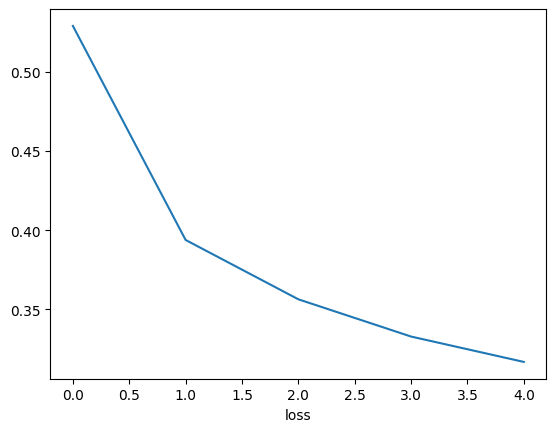

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.xlabel('loss')
plt.show()

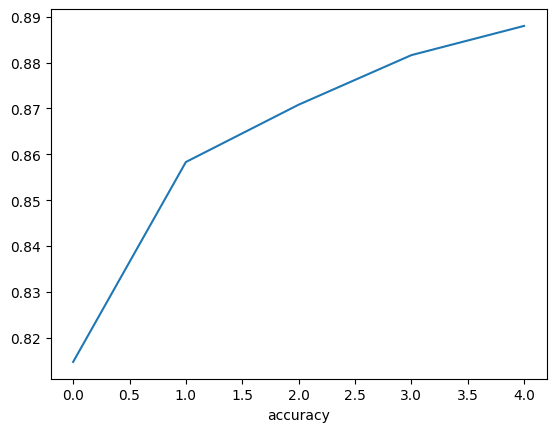

In [12]:
# History의 accuracy의 시각화

plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.xlabel('accuracy')
plt.show()

----
#### 반복 훈련의 증가 (epoch의 증가)

In [13]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics =['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 729us/step - accuracy: 0.8141 - loss: 0.5314
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 727us/step - accuracy: 0.8588 - loss: 0.3932
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - accuracy: 0.8727 - loss: 0.3525
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.8796 - loss: 0.3313
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.8862 - loss: 0.3143
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 622us/step - accuracy: 0.8910 - loss: 0.3037
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.8955 - loss: 0.2928
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step - accuracy: 0.8997 - loss: 0.2834
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 646us/step - accuracy: 0.9019 - loss: 0.2769
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.9035 - loss: 0.2689
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step - accuracy: 0.9046 - loss: 0.2625
Epoch 12

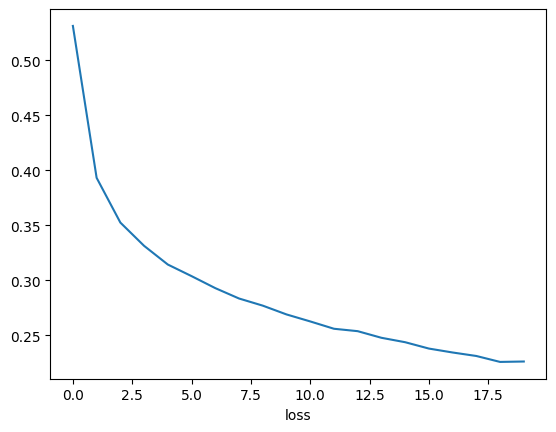

In [14]:
# History loss의 시각화

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.xlabel('loss')
plt.show()

> 훈련세트에만 정확도가 높고 검증세트나 테스트 세트에서는 정확도가 떨어지는 과대적합이 생길 수 있다.    
epoch를 무한정 늘리면 훈련세트에만 정확도가 높아질 수 있어 검증세트나 테스트 세트에서도 정확도가 높은 지점을 찾아야 한다. 

---
#### 검증 손실
: 검증세트에 대한 정확도를 파악하기 위해 validation_data를 사용한다.

In [19]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics =['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target)) # 학습할때 val_scaled, val_target 이것도 신경 쓰라는 거 

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8107 - loss: 0.5362 - val_accuracy: 0.8519 - val_loss: 0.4183
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.8576 - loss: 0.3971 - val_accuracy: 0.8684 - val_loss: 0.3776
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - accuracy: 0.8707 - loss: 0.3596 - val_accuracy: 0.8708 - val_loss: 0.3648
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.8784 - loss: 0.3355 - val_accuracy: 0.8722 - val_loss: 0.3722
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8837 - loss: 0.3206 - val_accuracy: 0.8732 - val_loss: 0.3653
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 985us/step - accuracy: 0.8894 - loss: 0.3061 - val_accuracy: 0.8835 - val_loss: 0.3562
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - accuracy: 0.8926 - loss: 0.2976 - val_accuracy: 0.8766 - val_loss: 0.3654
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8955 - loss:

In [20]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

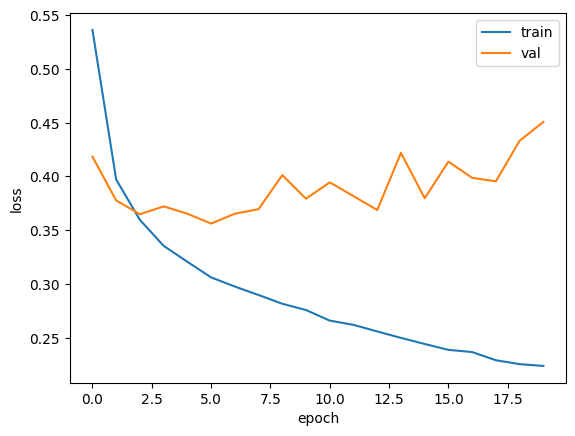

In [21]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

----
#### Optimizer 사용 (adam)

In [22]:
model = model_fn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics =['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target)) # 학습할때 val_scaled, val_target 이것도 신경 쓰라는 거 

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8177 - loss: 0.5249 - val_accuracy: 0.8389 - val_loss: 0.4449
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8603 - loss: 0.3908 - val_accuracy: 0.8645 - val_loss: 0.3900
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8730 - loss: 0.3512 - val_accuracy: 0.8689 - val_loss: 0.3693
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8811 - loss: 0.3246 - val_accuracy: 0.8786 - val_loss: 0.3430
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8881 - loss: 0.3044 - val_accuracy: 0.8759 - val_loss: 0.3493
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8932 - loss: 0.2909 - val_accuracy: 0.8812 - val_loss: 0.3317
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8987 - loss: 0.2765 - val_accuracy: 0.8817 - val_loss: 0.3282
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9014 - loss: 0.2658 

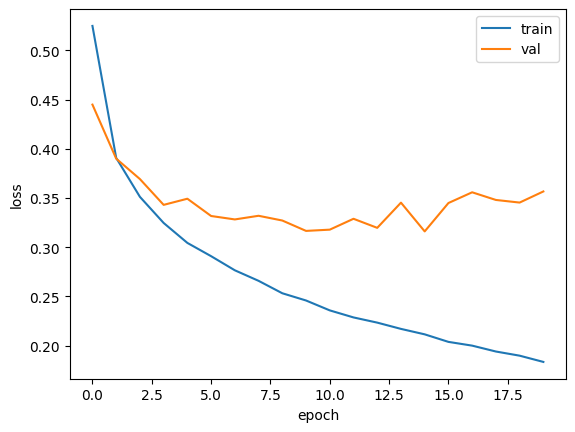

In [23]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

----
#### Dropout
- 과대 적합 방지를 위한 규제(머신러닝에서는 L1규제, L2규제) / 릿지 L2, 라쏘 L1
- 신경망 모델에서만 있음
- 훈련시에만 각 Sample을 처리할때 마다 은닉층의 임의의 neuron을 계산에 포함시키지 않는다.

In [24]:
# model에 dropout층을 추가
model = model_fn(keras.layers.Dropout(0.3)) # dropout을 30% 
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics =['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target)) # 학습할때 val_scaled, val_target 이것도 신경 쓰라는 거 

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7916 - loss: 0.5906 - val_accuracy: 0.8451 - val_loss: 0.4335
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8420 - loss: 0.4388 - val_accuracy: 0.8631 - val_loss: 0.3812
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8533 - loss: 0.4025 - val_accuracy: 0.8672 - val_loss: 0.3633
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8592 - loss: 0.3827 - val_accuracy: 0.8683 - val_loss: 0.3596
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.8650 - loss: 0.3670 - val_accuracy: 0.8737 - val_loss: 0.3454
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8699 - loss: 0.3530 - val_accuracy: 0.8779 - val_loss: 0.3366
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 999us/step - accuracy: 0.8748 - loss: 0.3411 - val_accuracy: 0.8748 - val_loss: 0.3404
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8759 - loss: 0.335

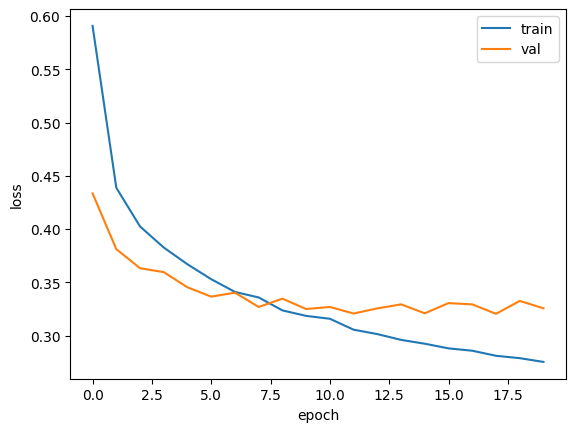

In [26]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

----
#### 모델의 저장과 복원

In [28]:
# 저장
model.save("../Data/model_whole.keras")

In [29]:
# 사용
model1 = keras.models.load_model("../Data/model_whole.keras")

In [30]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.8839 - loss: 0.3257


[0.3256879150867462, 0.8839166760444641]

----
#### Callbacks
: 훈련수행시 손실값이 제일 작은 함수를 저장해준다. <- 굉장히 편함


In [ ]:
# # model에 dropout층을 추가
# model = model_fn(keras.layers.Dropout(0.3)) # dropout을 30% 
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics =['accuracy'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_model.keras")

# history = model.fit(train_scaled, train_target, epochs=20, 
#                     validation_data=(val_scaled, val_target),
#                     callback = [checkpoint_cb] # 학습 옵션 추가함
# ) # 학습할때 val_scaled, val_target 이것도 신경 쓰라는 거 

TypeError: TensorFlowTrainer.fit() got an unexpected keyword argument 'callback'. Did you mean 'callbacks'?

In [35]:
# model에 dropout층을 추가 
model =model_fn(keras.layers.Dropout(0.3)) #dropout을 30% 
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')
history = model.fit(
    train_scaled,train_target,epochs=20,
                    validation_data=(val_scaled,val_target),
                    callbacks = [checkpoint_cb]
                    
                    
                    )

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7898 - loss: 0.5964 - val_accuracy: 0.8342 - val_loss: 0.4468
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8401 - loss: 0.4459 - val_accuracy: 0.8536 - val_loss: 0.3966
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8495 - loss: 0.4102 - val_accuracy: 0.8653 - val_loss: 0.3720
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8590 - loss: 0.3857 - val_accuracy: 0.8714 - val_loss: 0.3484
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8642 - loss: 0.3688 - val_accuracy: 0.8748 - val_loss: 0.3420
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8684 - loss: 0.3573 - val_accuracy: 0.8731 - val_loss: 0.3425
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8733 - loss: 0.3471 - val_accuracy: 0.8770 - val_loss: 0.3374
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8763 - loss: 0.3348 - 

In [36]:
# 사용
model1 = keras.models.load_model("../Data/best_model.keras")
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.8874 - loss: 0.3224


[0.3224439322948456, 0.887416660785675]

----
#### Early-Stopping(조기종료)
: Callbacks를 끝까지 기다리는 것이 아니고 Hyper Parameter(patience)을 선정하여 한계값을 정해 실행한다.

In [37]:
# model에 dropout층을 추가 
model =model_fn(keras.layers.Dropout(0.3)) #dropout을 30% 
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)
history = model.fit(
    train_scaled,train_target,epochs=20,
                    validation_data=(val_scaled,val_target),
                    callbacks = [checkpoint_cb,early_stopping_cb]
                    
                    
                    )

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7908 - loss: 0.5921 - val_accuracy: 0.8418 - val_loss: 0.4318
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8437 - loss: 0.4355 - val_accuracy: 0.8470 - val_loss: 0.4278
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8555 - loss: 0.3989 - val_accuracy: 0.8687 - val_loss: 0.3587
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8634 - loss: 0.3797 - val_accuracy: 0.8673 - val_loss: 0.3646
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8679 - loss: 0.3654 - val_accuracy: 0.8718 - val_loss: 0.3474
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8709 - loss: 0.3528 - val_accuracy: 0.8709 - val_loss: 0.3435
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8736 - loss: 0.3441 - val_accuracy: 0.8788 - val_loss: 0.3327
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.8763 - loss: 0.3342 

In [38]:
# 몇번째 epochs에서 stop 되었는가
early_stopping_cb.stopped_epoch

15

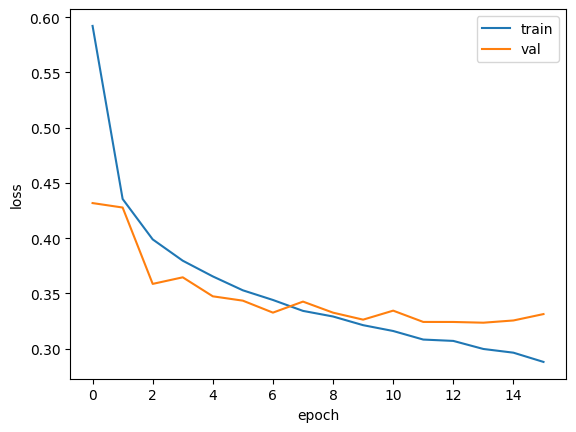

In [39]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [40]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8823 - loss: 0.3235


[0.3235456049442291, 0.8823333382606506]